<a href="https://colab.research.google.com/github/Ashok-nimmala/EXAPLAINABLE-AI/blob/main/poject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(1470, 35)
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWork

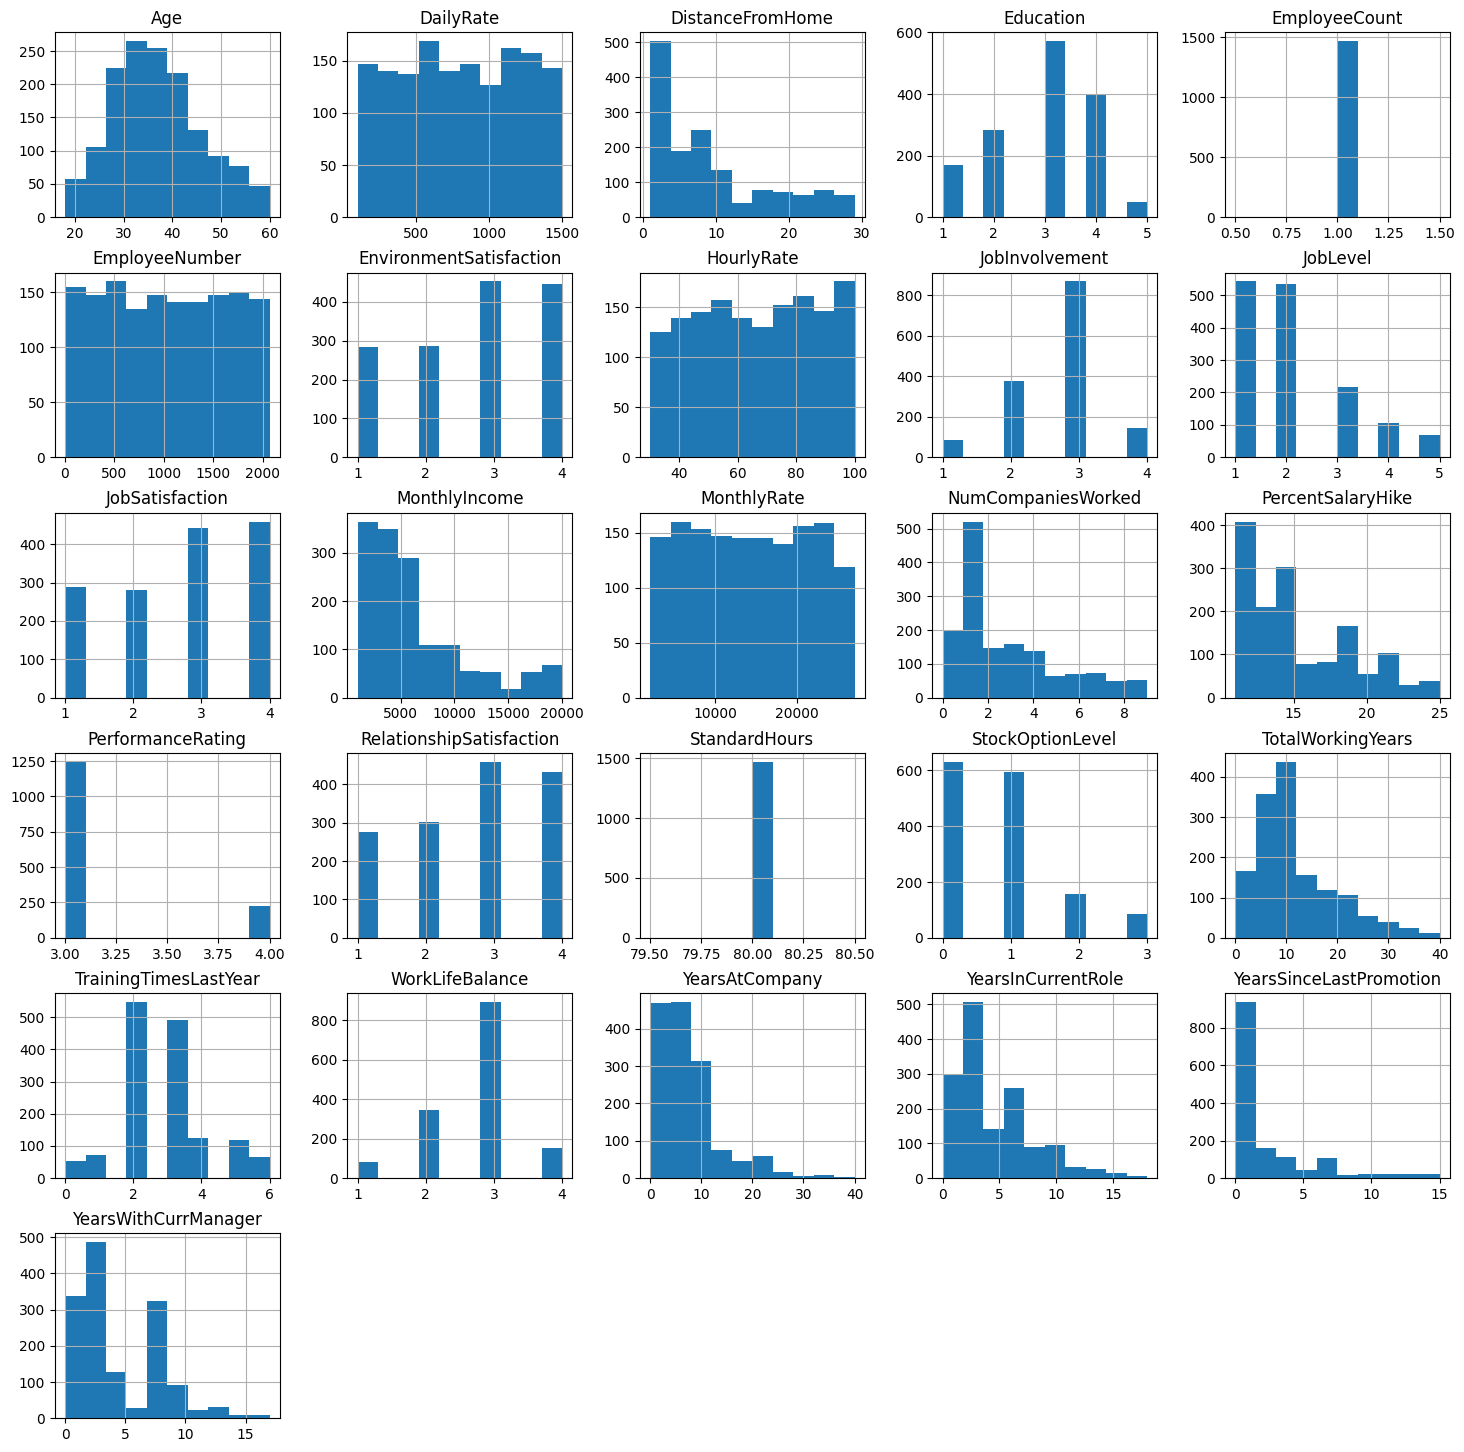

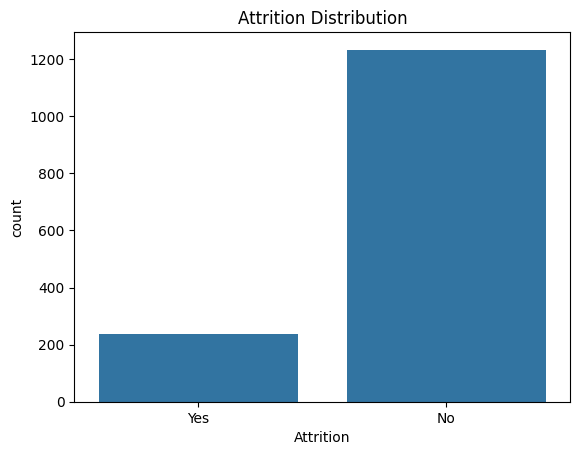

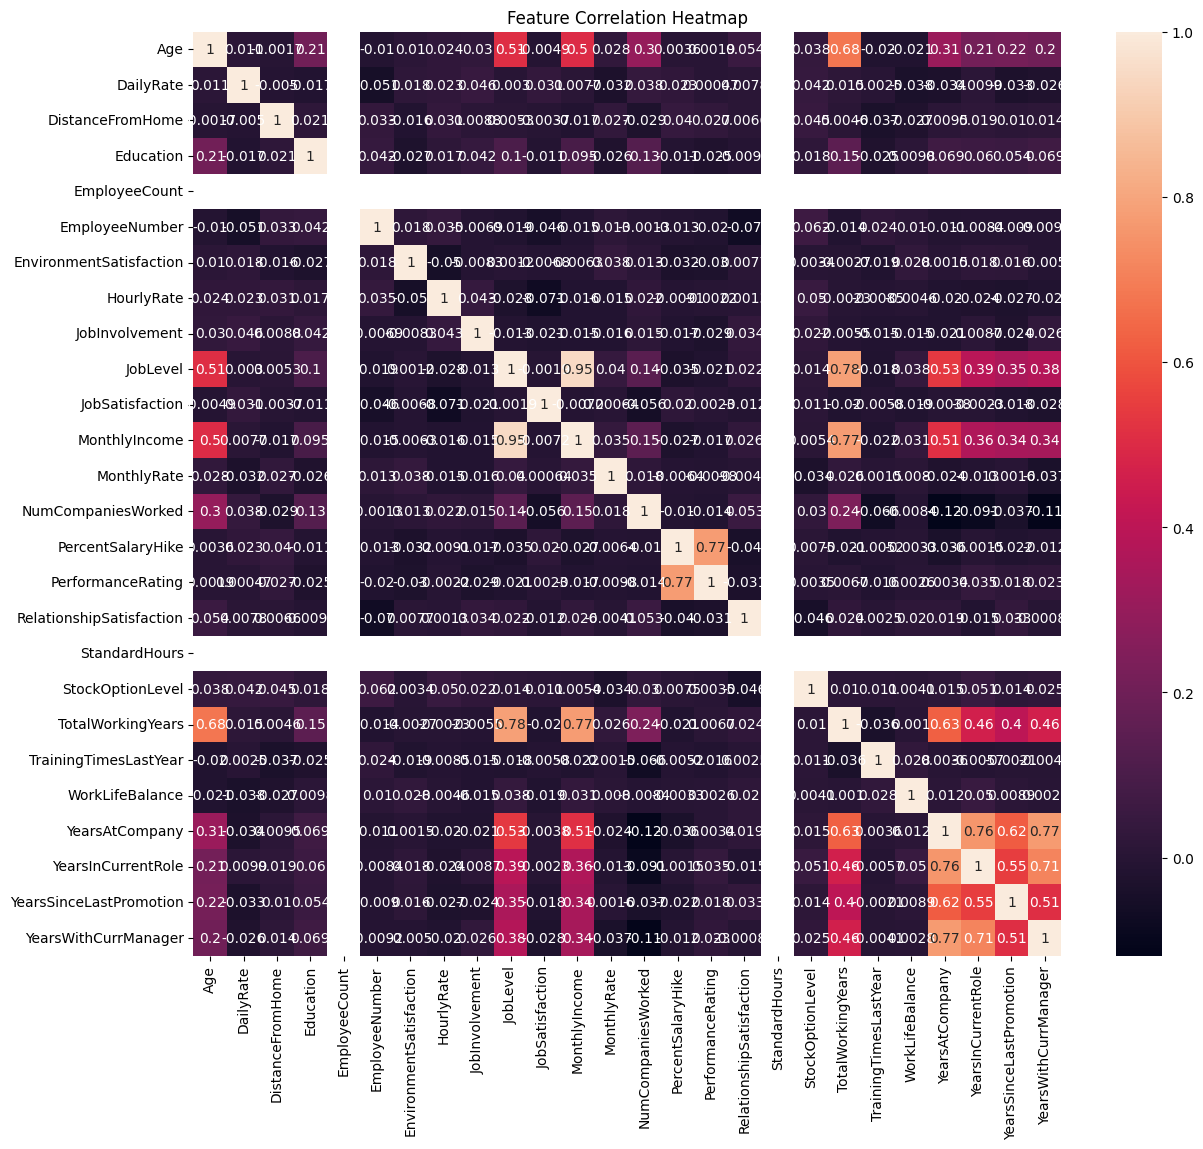

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Inspect shape and datatypes
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

# Summary statistics
print(df.describe(include='all'))

# Visualize distributions
df.hist(figsize=(18,18))
plt.show()

# Attrition balance
sns.countplot(data=df, x='Attrition')
plt.title('Attrition Distribution')
plt.show()

# Correlation heatmap
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()


In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Binary label encoding Attrition (target)
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

# Encode categorical features
le = LabelEncoder()
for col in df.select_dtypes('object'):
    if df[col].nunique() == 2:
        df[col] = le.fit_transform(df[col])
    else:
        df = pd.get_dummies(df, columns=[col])

# Scale numerical features
scaler = StandardScaler()
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('Attrition')
df[num_cols] = scaler.fit_transform(df[num_cols])

# Train-test split
X = df.drop('Attrition', axis=1)
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })
df_results = pd.DataFrame(results)
print(df_results)


                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.860544   0.615385  0.340426  0.438356  0.810923
1        Decision Tree  0.768707   0.301887  0.340426  0.320000  0.595314
2        Random Forest  0.843537   0.571429  0.085106  0.148148  0.774442
3                  SVM  0.863946   0.769231  0.212766  0.333333  0.815919
4                  KNN  0.843537   0.545455  0.127660  0.206897  0.652812
5    Gradient Boosting  0.857143   0.666667  0.212766  0.322581  0.797743


In [4]:
import tensorflow as tf
from sklearn.metrics import confusion_matrix

# Build MLP
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Evaluate
y_pred_dl = (model.predict(X_test) > 0.5).astype('int32')
from sklearn.metrics import f1_score
print("MLP F1 Score:", f1_score(y_test, y_pred_dl))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dl))


Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7538 - loss: 0.5428 - val_accuracy: 0.8401 - val_loss: 0.4531
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8410 - loss: 0.3934 - val_accuracy: 0.8401 - val_loss: 0.4183
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8232 - loss: 0.3871 - val_accuracy: 0.8435 - val_loss: 0.3955
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8768 - loss: 0.2901 - val_accuracy: 0.8707 - val_loss: 0.3829
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8746 - loss: 0.3136 - val_accuracy: 0.8810 - val_loss: 0.3673
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9045 - loss: 0.2751 - val_accuracy: 0.8741 - val_loss: 0.3660
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8964 - loss: 0.2866 - val_accuracy: 0.8741 - val_loss: 0.3616
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9022 - loss: 0.2701 - val_accuracy: 0.8707 - val_loss

In [6]:
%pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=80320feeddb12d989bc63317524b64f2ba1348c737dc06a17ab0d2d5d069cf3a
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


Feature Importance (Random Forest):


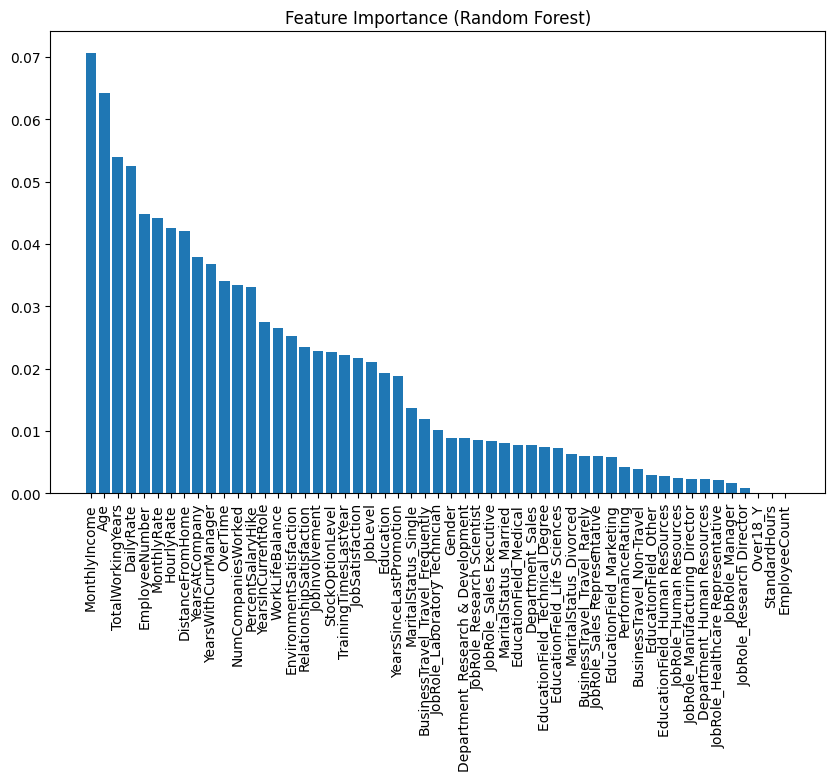


SHAP Plots:
SHAP Feature Importance (Bar Plot):


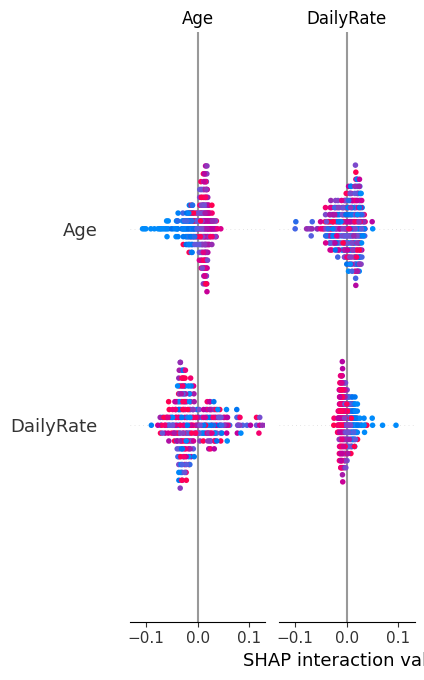

SHAP Beeswarm Plot:


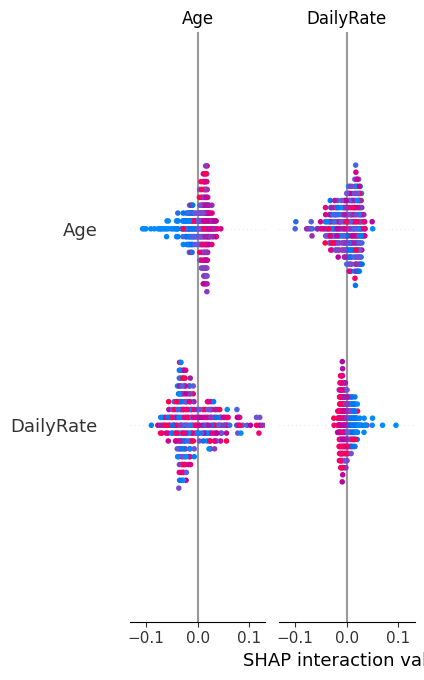


LIME Explanations for a Test Instance:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



PDP/ICE Plot for: MonthlyIncome


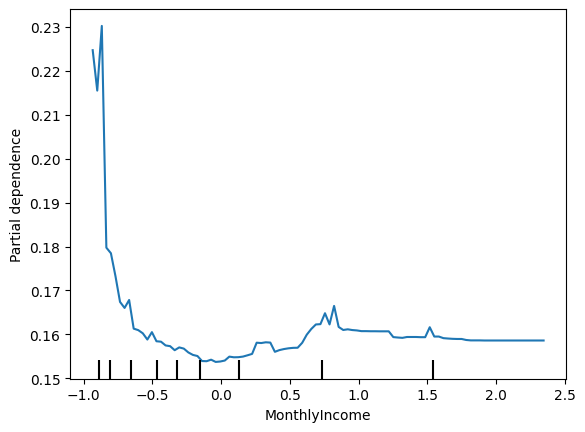

In [10]:
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
import lime.lime_tabular

# Fit random forest model (if not already)
rf = RandomForestClassifier().fit(X_train, y_train)

# --- Feature Importance ---
print("Feature Importance (Random Forest):")
importances = rf.feature_importances_
indices = importances.argsort()[::-1]
plt.figure(figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(X_train.shape[1]), importances[indices])
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.show()

# --- SHAP Plots ---
print("\nSHAP Plots:")
shap_explainer = shap.TreeExplainer(rf)
shap_values = shap_explainer.shap_values(X_test)

if isinstance(shap_values, list):
    chosen_shap = shap_values[1] if shap_values[1].shape == X_test.shape else shap_values[0]
    print("SHAP Feature Importance (Bar Plot):")
    shap.summary_plot(chosen_shap, X_test, plot_type="bar")
    print("SHAP Beeswarm Plot:")
    shap.summary_plot(chosen_shap, X_test)
else:
    print("SHAP Feature Importance (Bar Plot):")
    shap.summary_plot(shap_values, X_test, plot_type="bar")
    print("SHAP Beeswarm Plot:")
    shap.summary_plot(shap_values, X_test)

# --- LIME Plot ---
print("\nLIME Explanations for a Test Instance:")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=X_train.columns,
    class_names=['No', 'Yes'],
    mode='classification'
)
i = 0  # Index of X_test to explain
lime_exp = lime_explainer.explain_instance(X_test.values[i], rf.predict_proba)
lime_exp.show_in_notebook()

# --- PDP/ICE Plots ---
feature_name = 'MonthlyIncome'  # Example feature to plot
print(f"\nPDP/ICE Plot for: {feature_name}")
if feature_name in X_train.columns:
    PartialDependenceDisplay.from_estimator(rf, X_train, [feature_name], feature_names=X_train.columns)
    plt.show()
else:
    print(f"Feature '{feature_name}' not found in dataset.")
